# Correlation Matrices Analysis and Eigendecomposition

In this notebook we perform a comprehensive analysis of correlation matrices stored in `corr_windows_tensor.pt`, including:
- **Correlation value distribution analysis**: Examining the statistical properties of all pairwise correlations across all time windows
- **Eigendecomposition**: Computing eigenvalues and eigenvectors for each correlation matrix

## Correlation Values Analysis

We extract and analyze all unique correlation values from the upper triangular part of each correlation matrix. This provides insights into:
- The overall correlation structure of the asset market
- Distribution of positive vs. negative correlations
- Temporal evolution of correlation patterns

## Eigendecomposition of Correlation Matrices

The eigendecomposition of correlation matrices provides insights into the principal components (principal correlations) of the asset market and their evolution over time.

For a symmetric correlation matrix $C \in \mathbb{R}^{n \times n}$, we compute:
- $\lambda_i$: eigenvalues (sorted in descending order)
- $v_i$: corresponding eigenvectors

The explained variance ratio for the $k$-th eigenvalue is:
$$
\text{EV}_k = \frac{\lambda_k}{\sum_{i=1}^{n} \lambda_i}
$$

This helps us understand which principal correlations dominate the market structure and how many principal components are needed to explain the variance in the correlation matrix.

In [1]:
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

torch.set_printoptions(linewidth=200, precision=4, sci_mode=False)

# Global matrix selection for all analyses in this notebook
# Options:
#   - 'all': use all windows
#   - integer (0 to num_windows-1): use one window
#   - 'start:stop' (e.g., '0:100'): use a window range
SELECTED_CORR_MATRIX = 0
FILE_NAME = 'data_13_17'
WINDOW_LENGTH = 660
STRIDE = 1

In [2]:
def parse_selected_corr_matrix(selected_corr_matrix, num_matrices):
    """Return selected indices, display label, and selection type (all/range/single)."""
    if selected_corr_matrix == 'all':
        return np.arange(num_matrices), 'All Windows', 'all'
    if isinstance(selected_corr_matrix, str) and ':' in selected_corr_matrix:
        start_str, stop_str = selected_corr_matrix.split(':')
        start_idx, stop_idx = int(start_str), int(stop_str)
        if not (0 <= start_idx < stop_idx <= num_matrices):
            raise ValueError(
                f"Invalid SELECTED_CORR_MATRIX range: {selected_corr_matrix}. Expected 'start:stop' with 0 <= start < stop <= {num_matrices}."
            )
        return np.arange(start_idx, stop_idx), f'Windows {start_idx}:{stop_idx}', 'range'

    matrix_idx = int(selected_corr_matrix)
    if not (0 <= matrix_idx < num_matrices):
        raise ValueError(
            f"Invalid SELECTED_CORR_MATRIX index: {matrix_idx}. Valid range is [0, {num_matrices - 1}]."
        )
    return np.array([matrix_idx]), f'Matrix {matrix_idx}', 'single'

def extract_and_sanitize_correlation_matrix(corr_tensor_input, matrix_idx):
    if hasattr(corr_tensor_input, 'cpu'):
        # It's a torch tensor
        corr_matrix = corr_tensor_input[matrix_idx].cpu().numpy()
    else:
        # It's already numpy
        corr_matrix = np.array(corr_tensor_input[matrix_idx], dtype=float)
    
    corr_matrix = np.clip(corr_matrix, -1.0, 1.0)
    corr_matrix = (corr_matrix + corr_matrix.T) / 2.0
    np.fill_diagonal(corr_matrix, 1.0)
    
    return corr_matrix

def build_distance_matrix(corr_matrix):
    dist_matrix = np.sqrt(np.maximum(0.0, 2.0 * (1.0 - corr_matrix)))
    dist_matrix = (dist_matrix + dist_matrix.T) / 2.0
    np.fill_diagonal(dist_matrix, 0.0)
    
    return dist_matrix

In [3]:
# ===== SET UP RESULTS FOLDER =====
RESULTS_BASE = Path('../results')
RESULTS_MAIN_FOLDER = RESULTS_BASE / f'{FILE_NAME}_w{WINDOW_LENGTH}_s{STRIDE}'
RESULTS_MAIN_FOLDER.mkdir(parents=True, exist_ok=True)

if SELECTED_CORR_MATRIX == 'all':
    subfolder_name = 'all'
elif isinstance(SELECTED_CORR_MATRIX, str) and ':' in SELECTED_CORR_MATRIX:
    start, stop = SELECTED_CORR_MATRIX.split(':')
    subfolder_name = f'windows_{start}_{stop}'
else:
    subfolder_name = f'matrix_{SELECTED_CORR_MATRIX}'

RESULTS_FOLDER = RESULTS_MAIN_FOLDER / subfolder_name
RESULTS_FOLDER.mkdir(parents=True, exist_ok=True)

print(f"Selected analysis: {SELECTED_CORR_MATRIX}")
print(f"Results will be saved to: {RESULTS_FOLDER.resolve()}")

Selected analysis: 0
Results will be saved to: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\results\data_13_17_w660_s1\matrix_0


## Section 1: Load Correlation Matrices Dataset

Load the correlation matrices dataset from the saved PyTorch file and extract all components needed for eigendecomposition analysis.

In [4]:
TENSOR_PATH = Path(f'../data/processed/corr_windows_tensor_{FILE_NAME}_w{WINDOW_LENGTH}_s{STRIDE}.pt')
checkpoint = torch.load(TENSOR_PATH)

corr_tensor = checkpoint['corr_tensor']
window_ranges = checkpoint['window_ranges']
window_length = checkpoint['window_length']
stride = checkpoint['stride']
tickers = checkpoint['tickers']

num_windows = corr_tensor.shape[0]
num_assets = corr_tensor.shape[1]

print(f'Tensor loaded from: {TENSOR_PATH.resolve()}')
print('\n--- Loaded Data Structure ---')
print(f"corr_tensor shape: {corr_tensor.shape}")
print(f"  - Dimension 0 (num_windows): {corr_tensor.shape[0]} rolling windows")
print(f"  - Dimension 1 (num_assets): {corr_tensor.shape[1]} assets")
print(f"  - Dimension 2 (num_assets): {corr_tensor.shape[2]} assets (symmetric matrix)")
print(f"window_length: {window_length} days per window")
print(f"stride: {stride} days between consecutive windows")
print(f"num_tickers: {len(tickers)} tickers")
print(f"tickers (first 5): {tickers[:5]}")
print(f"window_ranges (first 3): {window_ranges[:3]}")

Tensor loaded from: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\data\processed\corr_windows_tensor_data_13_17_w660_s1.pt

--- Loaded Data Structure ---
corr_tensor shape: torch.Size([597, 335, 335])
  - Dimension 0 (num_windows): 597 rolling windows
  - Dimension 1 (num_assets): 335 assets
  - Dimension 2 (num_assets): 335 assets (symmetric matrix)
window_length: 660 days per window
stride: 1 days between consecutive windows
num_tickers: 335 tickers
tickers (first 5): ['BBY', 'CSCO', 'TSN', 'KMI', 'GT']
window_ranges (first 3): [(0, 660), (1, 661), (2, 662)]


## Section 2: Correlation Matrices Analysis
### Property 1: The distribution of pairwise correlations is significantly shifted towards positive values

Extract all correlation values from the matrices and analyze their distribution using histograms and statistics.

--- Correlation Values Statistics (Matrix 0) ---

Total number of correlation values: 55945
Mean correlation: 0.3532
Std deviation: 0.1158
Min correlation: -0.0263
Max correlation: 0.8879
Median correlation: 0.3466

Correlation sign distribution:
  Positive (> 0): 55942 (99.99%)
  Negative (< 0): 3 (0.01%)
  Zero (= 0): 0 (0.00%)

✓ Plot saved to: ..\results\data_13_17_w660_s1\matrix_0\01_correlation_values_distribution.png


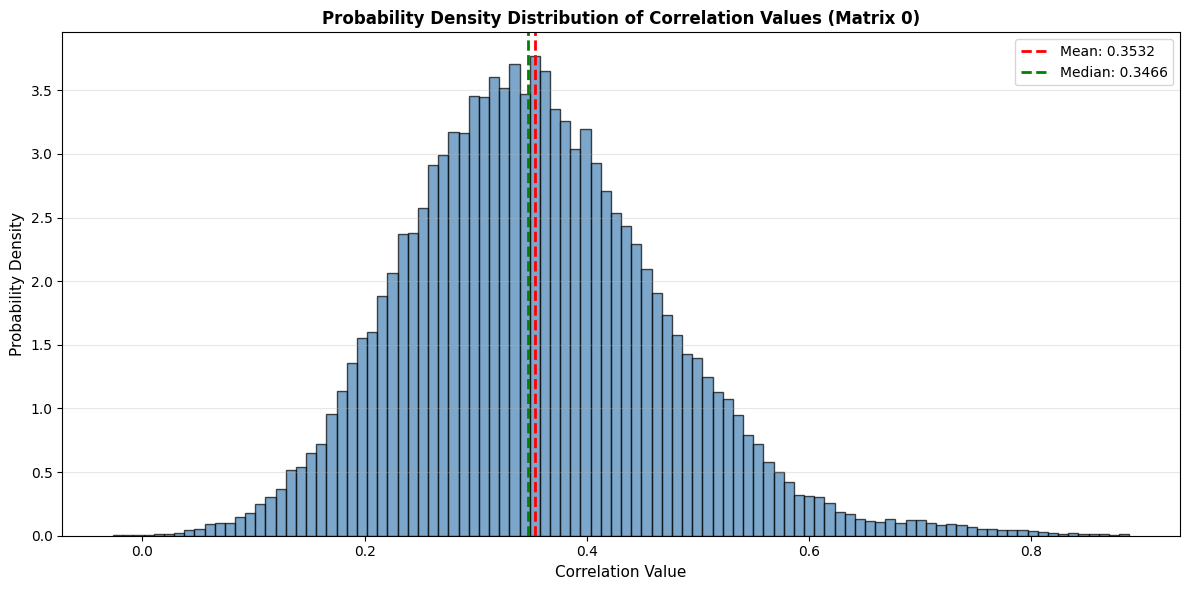


✓ Correlation value probability density visualization complete!


In [5]:
# Extract correlation values from the tensor
# Extract upper triangular indices (excluding diagonal)
triu_indices = torch.triu_indices(num_assets, num_assets, offset=1)
all_corr_values = []

selected_indices, corr_title, _ = parse_selected_corr_matrix(SELECTED_CORR_MATRIX, num_windows)

for i in selected_indices:
    corr_matrix = corr_tensor[i]
    # Get all unique correlation values (upper triangular part)
    corr_values = corr_matrix[triu_indices[0], triu_indices[1]]
    all_corr_values.append(corr_values)

# Concatenate all correlation values
all_corr_values_flat = torch.cat(all_corr_values)

print(f"--- Correlation Values Statistics ({corr_title}) ---\n")
print(f"Total number of correlation values: {len(all_corr_values_flat)}")
print(f"Mean correlation: {torch.mean(all_corr_values_flat):.4f}")
print(f"Std deviation: {torch.std(all_corr_values_flat):.4f}")
print(f"Min correlation: {torch.min(all_corr_values_flat):.4f}")
print(f"Max correlation: {torch.max(all_corr_values_flat):.4f}")
print(f"Median correlation: {torch.median(all_corr_values_flat):.4f}")

# Count positive and negative correlations
positive_corrs = torch.sum(all_corr_values_flat > 0).item()
negative_corrs = torch.sum(all_corr_values_flat < 0).item()
zero_corrs = torch.sum(all_corr_values_flat == 0).item()

print(f"\nCorrelation sign distribution:")
print(f"  Positive (> 0): {positive_corrs} ({100*positive_corrs/len(all_corr_values_flat):.2f}%)")
print(f"  Negative (< 0): {negative_corrs} ({100*negative_corrs/len(all_corr_values_flat):.2f}%)")
print(f"  Zero (= 0): {zero_corrs} ({100*zero_corrs/len(all_corr_values_flat):.2f}%)")

# Visualization of correlation values as probability density
fig, ax = plt.subplots(figsize=(12, 6))

# Histogram of all correlation values with normalized density
ax.hist(all_corr_values_flat.numpy(), bins=100, color='steelblue', edgecolor='black', alpha=0.7, density=True)
ax.axvline(torch.mean(all_corr_values_flat).item(), color='red', linestyle='--', linewidth=2, label=f'Mean: {torch.mean(all_corr_values_flat):.4f}')
ax.axvline(torch.median(all_corr_values_flat).item(), color='green', linestyle='--', linewidth=2, label=f'Median: {torch.median(all_corr_values_flat):.4f}')
ax.set_xlabel('Correlation Value', fontsize=11)
ax.set_ylabel('Probability Density', fontsize=11)
ax.set_title(f'Probability Density Distribution of Correlation Values ({corr_title})', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()

# Save the figure
plot_path = RESULTS_FOLDER / '01_correlation_values_distribution.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
print(f"\n✓ Plot saved to: {plot_path}")

plt.show()

print("\n✓ Correlation value probability density visualization complete!")

### Property 2: Eigenvalues follow the Marchenko–Pastur distribution, except for a very large first eigenvalue and a couple of other large eigenvalues

For each correlation matrix, compute eigenvalues and eigenvectors using `torch.linalg.eigh()`. This function returns eigenvalues in ascending order.

In [6]:
# Compute eigenvalues and eigenvectors for each correlation matrix
num_windows = corr_tensor.shape[0]
num_assets = corr_tensor.shape[1]

eigenvalues_list = []
eigenvectors_list = []

print(f"Computing eigendecomposition for {num_windows} correlation matrices...")

for i in range(num_windows):
    # Get the i-th correlation matrix
    corr_matrix = corr_tensor[i]
    
    # Compute eigenvalues and eigenvectors
    # torch.linalg.eigh returns eigenvalues in ascending order
    evals, evecs = torch.linalg.eigh(corr_matrix)
    
    # Reverse to get descending order (highest eigenvalues first)
    evals = torch.flip(evals, dims=[0])
    evecs = torch.flip(evecs, dims=[1])
    
    eigenvalues_list.append(evals)
    eigenvectors_list.append(evecs)
    
    if (i + 1) % 100 == 0:
        print(f"  Processed {i + 1}/{num_windows} windows")

# Convert lists to tensors
eigenvalues_tensor = torch.stack(eigenvalues_list, dim=0)  # Shape: (num_windows, num_assets)
eigenvectors_tensor = torch.stack(eigenvectors_list, dim=0)  # Shape: (num_windows, num_assets, num_assets)

print(f"\n✓ Eigendecomposition complete!")
print(f"eigenvalues_tensor shape: {eigenvalues_tensor.shape}")
print(f"eigenvectors_tensor shape: {eigenvectors_tensor.shape}")
print(f"\nFirst window eigenvalues (top 10): {eigenvalues_tensor[0, :10]}")

Computing eigendecomposition for 597 correlation matrices...
  Processed 100/597 windows
  Processed 200/597 windows
  Processed 300/597 windows
  Processed 400/597 windows
  Processed 500/597 windows

✓ Eigendecomposition complete!
eigenvalues_tensor shape: torch.Size([597, 335])
eigenvectors_tensor shape: torch.Size([597, 335, 335])

First window eigenvalues (top 10): tensor([122.8973,  18.0639,  10.6887,   5.1529,   4.4332,   4.0803,   3.7195,   3.5605,   2.9015,   2.7152])



Statistics for Matrix 0:
Count: 335
Min: 0.026154
Max: 122.897301

Marchenko-Pastur bounds:
  a (lower bound): 0.082689
  b (upper bound): 2.932463

Eigenvalues ABOVE Marchenko-Pastur limit (b=2.932463):
   1. 122.897301
   2. 18.063919
   3. 10.688732
   4. 5.152880
   5. 4.433163
   6. 4.080316
   7. 3.719493
   8. 3.560488

Eigenvalues BELOW or WITHIN Marchenko-Pastur bounds: 327

✓ Plot saved to: ..\results\data_13_17_w660_s1\matrix_0\02_eigenvalue_distribution_marchenko_pastur.png


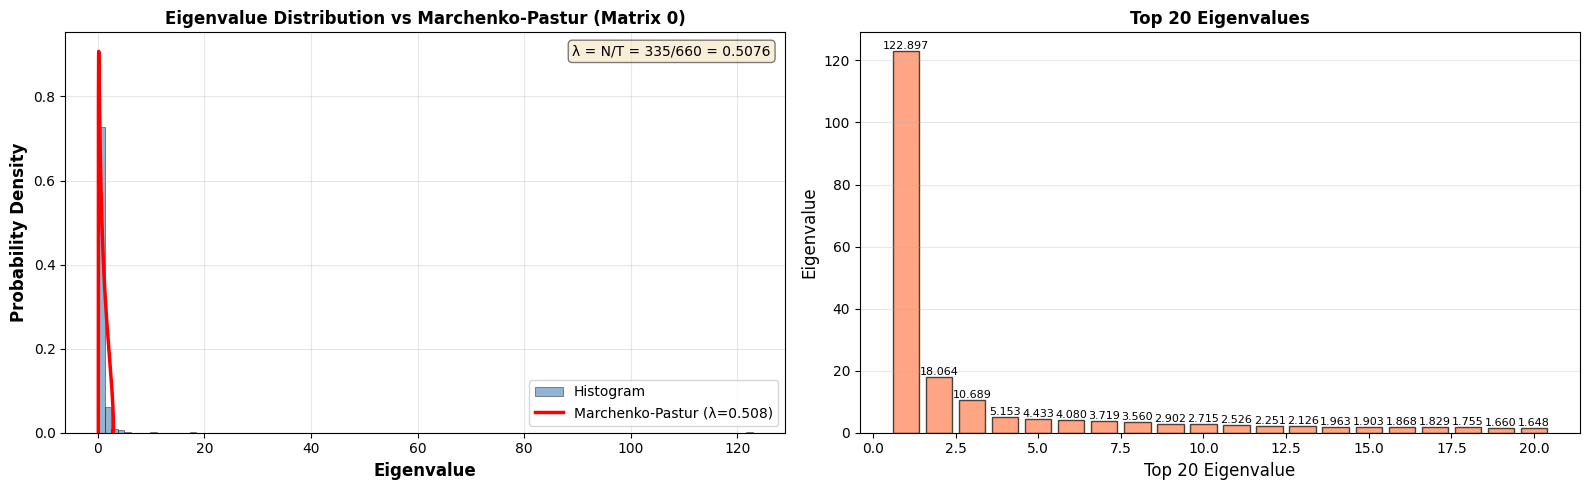

In [7]:
eigenvalues_np = eigenvalues_tensor.cpu().numpy()

# ===== MARCHENKO-PASTUR FUNCTION =====
def marchenko_pastur_pdf(x, lmbd, sigma=1):
    """
    Marchenko-Pastur probability density function.

    Parameters:
    -----------
    x : float or array
        Eigenvalue
    lmbd : float
        Ratio of num_eigenvalues / num_time_points (N/T)
    sigma : float
        Standard deviation (typically 1 for correlation matrices)

    Returns:
    --------
    float or array
        Probability density at x
    """
    b = np.power(sigma * (1 + np.sqrt(lmbd)), 2)  # Largest eigenvalue
    a = np.power(sigma * (1 - np.sqrt(lmbd)), 2)  # Smallest eigenvalue

    # Vectorized calculation
    result = np.zeros_like(x, dtype=float)
    mask = (x >= a) & (x <= b)
    result[mask] = (1 / (2 * np.pi * sigma * sigma * x[mask] * lmbd)) * np.sqrt((b - x[mask]) * (x[mask] - a))

    return result

# Select data based on global choice
selected_indices, selection_label, selection_type = parse_selected_corr_matrix(SELECTED_CORR_MATRIX, num_windows)
if selection_type == 'single':
    data = eigenvalues_np[selected_indices[0]]
else:
    data = eigenvalues_np[selected_indices].flatten()

# Clip negative values to 0 (numerical errors in correlation matrices)
# Eigenvalues of correlation matrices should be non-negative
data = np.clip(data, 0, None)

# Calculate Marchenko-Pastur parameters
# lambda = number of assets / window length
lmbd = num_assets / window_length
sigma = 1.0

# Create histogram with density=True for probability density
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left plot: Histogram with Marchenko-Pastur overlay
ax = axes[0]
n, bins, patches = ax.hist(data, bins=100, density=True, alpha=0.6,
                            color='steelblue', edgecolor='black', linewidth=0.5,
                            label='Histogram')

# Calculate Marchenko-Pastur bounds
b = np.power(sigma * (1 + np.sqrt(lmbd)), 2)  # Largest eigenvalue
a = np.power(sigma * (1 - np.sqrt(lmbd)), 2)  # Smallest eigenvalue

# Create x range for theoretical curve (excluding top eigenvalues)
x_min = a
x_max = b

x_theory = np.linspace(x_min, x_max, 500)
y_theory = marchenko_pastur_pdf(x_theory, lmbd, sigma)

# Plot the theoretical Marchenko-Pastur density
ax.plot(x_theory, y_theory, 'r-', linewidth=2.5, label=f'Marchenko-Pastur (λ={lmbd:.3f})')

ax.set_xlabel('Eigenvalue', fontsize=12, fontweight='bold')
ax.set_ylabel('Probability Density', fontsize=12, fontweight='bold')
ax.set_title(f'Eigenvalue Distribution vs Marchenko-Pastur ({selection_label})', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Add text annotation with lambda value
textstr = f'λ = N/T = {num_assets}/{window_length} = {lmbd:.4f}'
ax.text(0.98, 0.97, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Right plot: Top eigenvalues as bar chart
ax = axes[1]
if selection_type == 'single':
    eigenvalues = eigenvalues_np[selected_indices[0]]
else:
    # For all/range selections, show sorted mean eigenvalues
    eigenvalues = eigenvalues_np[selected_indices].mean(axis=0)

# Sort in descending order and take top values
top_k = min(20, len(eigenvalues))
top_eigenvalues = np.sort(eigenvalues)[::-1][:top_k]
ranks = np.arange(1, top_k + 1)

ax.bar(ranks, top_eigenvalues, color='coral', edgecolor='black', alpha=0.7)
ax.set_xlabel('Top 20 Eigenvalue', fontsize=12)
ax.set_ylabel('Eigenvalue', fontsize=12)
ax.set_title(f'Top {top_k} Eigenvalues', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (rank, val) in enumerate(zip(ranks, top_eigenvalues)):
    ax.text(rank, val, f'{val:.3f}', ha='center', va='bottom', fontsize=8)

# Print statistics
print(f"\n{'='*50}")
print(f"Statistics for {selection_label}:")
print(f"{'='*50}")
print(f"Count: {len(data)}")
print(f"Min: {np.min(data):.6f}")
print(f"Max: {np.max(data):.6f}")
print(f"\nMarchenko-Pastur bounds:")
print(f"  a (lower bound): {a:.6f}")
print(f"  b (upper bound): {b:.6f}")

# Identify eigenvalues above the Marchenko-Pastur limit (anomalies)
if selection_type == 'single':
    eigenvalues_full = eigenvalues_np[selected_indices[0]]
else:
    eigenvalues_full = eigenvalues_np[selected_indices].mean(axis=0)

eigenvalues_above_b = eigenvalues_full[eigenvalues_full > b]

print(f"\nEigenvalues ABOVE Marchenko-Pastur limit (b={b:.6f}):")
if len(eigenvalues_above_b) > 0:
    for i, val in enumerate(sorted(eigenvalues_above_b, reverse=True), 1):
        print(f"  {i:2d}. {val:.6f}")
else:
    print("  (None)")

print(f"\nEigenvalues BELOW or WITHIN Marchenko-Pastur bounds: {len(eigenvalues_full) - len(eigenvalues_above_b)}")
print(f"{'='*50}\n")

plt.tight_layout()

# Save the figure
plot_path = RESULTS_FOLDER / '02_eigenvalue_distribution_marchenko_pastur.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
print(f"✓ Plot saved to: {plot_path}")

plt.show()

### Explained Variance by Top-4 Eigenvalues

Analyze the cumulative explained variance captured by the first 4 eigenvalues. This shows what percentage of the total variance is explained by the largest eigenvalues across all correlation matrices.

--- Explained Variance by Top-4 Eigenvalues ---

Total windows analyzed: 597

Statistics across all windows:
  λ₁ / Σλ:
    Mean: 0.3451
    Std:  0.0215
    Min:  0.2984
    Max:  0.3701

  (λ₁ + λ₂) / Σλ:
    Mean: 0.4125
    Std:  0.0161

  (λ₁ + λ₂ + λ₃) / Σλ:
    Mean: 0.4479
    Std:  0.0168

  (λ₁ + λ₂ + λ₃ + λ₄) / Σλ:
    Mean: 0.4663
    Std:  0.0157

✓ Plot saved to: ..\results\data_13_17_w660_s1\matrix_0\03_explained_variance_top4.png


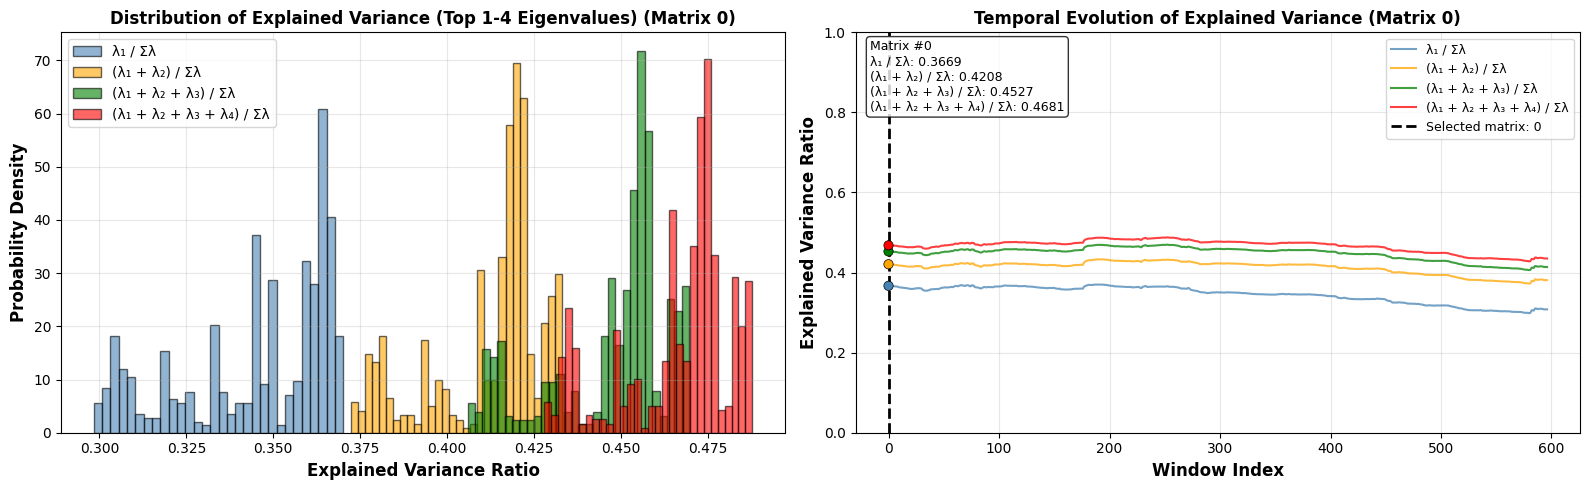


✓ Explained variance analysis complete!


In [8]:
# Compute cumulative explained variance for top-4 eigenvalues
def compute_explained_variance_top4(eigenvalues_np):
    """
    Compute the cumulative explained variance for the top 4 eigenvalues across all matrices.
    
    Parameters:
    -----------
    eigenvalues_np : np.ndarray
        Shape (num_matrices, num_eigenvalues), sorted in descending order
    
    Returns:
    --------
    explained_variance : np.ndarray
        Shape (num_matrices, 4) containing:
        - Column 0: λ₁ / Σλ
        - Column 1: (λ₁ + λ₂) / Σλ
        - Column 2: (λ₁ + λ₂ + λ₃) / Σλ
        - Column 3: (λ₁ + λ₂ + λ₃ + λ₄) / Σλ
    """
    num_matrices = eigenvalues_np.shape[0]
    explained_variance = np.empty((num_matrices, 4))
    
    for i in range(num_matrices):
        eigenvals = eigenvalues_np[i]
        total_sum = np.sum(eigenvals)
        
        # Compute cumulative sums of top 4 eigenvalues, normalized by total sum
        top4_cumsum = np.cumsum(eigenvals[:4])
        explained_variance[i, :] = top4_cumsum / total_sum
    
    return explained_variance


explained_variance = compute_explained_variance_top4(eigenvalues_np)
num_windows_ev = explained_variance.shape[0]
selected_indices, selection_label, selection_type = parse_selected_corr_matrix(SELECTED_CORR_MATRIX, num_windows_ev)

print(f"--- Explained Variance by Top-4 Eigenvalues ---\n")
print(f"Total windows analyzed: {explained_variance.shape[0]}")
print(f"\nStatistics across all windows:")
print(f"  λ₁ / Σλ:")
print(f"    Mean: {np.mean(explained_variance[:, 0]):.4f}")
print(f"    Std:  {np.std(explained_variance[:, 0]):.4f}")
print(f"    Min:  {np.min(explained_variance[:, 0]):.4f}")
print(f"    Max:  {np.max(explained_variance[:, 0]):.4f}")

print(f"\n  (λ₁ + λ₂) / Σλ:")
print(f"    Mean: {np.mean(explained_variance[:, 1]):.4f}")
print(f"    Std:  {np.std(explained_variance[:, 1]):.4f}")

print(f"\n  (λ₁ + λ₂ + λ₃) / Σλ:")
print(f"    Mean: {np.mean(explained_variance[:, 2]):.4f}")
print(f"    Std:  {np.std(explained_variance[:, 2]):.4f}")

print(f"\n  (λ₁ + λ₂ + λ₃ + λ₄) / Σλ:")
print(f"    Mean: {np.mean(explained_variance[:, 3]):.4f}")
print(f"    Std:  {np.std(explained_variance[:, 3]):.4f}")

# Visualization: Overlaid histograms + temporal evolution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ===== Left Plot: Overlaid Histograms (Density) =====
ax = axes[0]
ax.hist(explained_variance[:, 0], bins=30, density=True, alpha=0.6, 
        label='λ₁ / Σλ', color='steelblue', edgecolor='black')
ax.hist(explained_variance[:, 1], bins=30, density=True, alpha=0.6, 
        label='(λ₁ + λ₂) / Σλ', color='orange', edgecolor='black')
ax.hist(explained_variance[:, 2], bins=30, density=True, alpha=0.6, 
        label='(λ₁ + λ₂ + λ₃) / Σλ', color='green', edgecolor='black')
ax.hist(explained_variance[:, 3], bins=30, density=True, alpha=0.6, 
        label='(λ₁ + λ₂ + λ₃ + λ₄) / Σλ', color='red', edgecolor='black')

ax.set_xlabel('Explained Variance Ratio', fontsize=12, fontweight='bold')
ax.set_ylabel('Probability Density', fontsize=12, fontweight='bold')
ax.set_title(f'Distribution of Explained Variance (Top 1-4 Eigenvalues) ({selection_label})', fontsize=12, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, alpha=0.3)

# ===== Right Plot: Time Series with selection-aware highlights =====
ax = axes[1]
series_labels = [
    'λ₁ / Σλ',
    '(λ₁ + λ₂) / Σλ',
    '(λ₁ + λ₂ + λ₃) / Σλ',
    '(λ₁ + λ₂ + λ₃ + λ₄) / Σλ',
]
series_colors = ['steelblue', 'orange', 'green', 'red']

mean_for_legend = np.mean(explained_variance, axis=0) if selection_type == 'all' else None

for i, (label, color) in enumerate(zip(series_labels, series_colors)):
    if mean_for_legend is not None:
        plot_label = f"{label} (mean={mean_for_legend[i]:.4f})"
    else:
        plot_label = label
    ax.plot(explained_variance[:, i], alpha=0.75, linewidth=1.5, color=color, label=plot_label)

if selection_type == 'single':
    selected_idx = int(selected_indices[0])
    selected_values = explained_variance[selected_idx, :]

    ax.axvline(
        selected_idx,
        color='black',
        linestyle='--',
        linewidth=2,
        label=f'Selected matrix: {selected_idx}'
    )
    ax.scatter(
        [selected_idx] * 4,
        selected_values,
        color=series_colors,
        edgecolor='black',
        linewidth=0.5,
        zorder=6,
        s=45,
    )

    value_text = "\n".join([f"{series_labels[j]}: {selected_values[j]:.4f}" for j in range(4)])
    ax.text(
        0.02,
        0.98,
        f"Matrix #{selected_idx}\n{value_text}",
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment='top',
        horizontalalignment='left',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
    )

elif selection_type == 'range':
    range_start = int(selected_indices[0])
    range_end = int(selected_indices[-1])
    range_means = np.mean(explained_variance[selected_indices], axis=0)

    ax.axvline(
        range_start,
        color='black',
        linestyle='--',
        linewidth=2,
        label=f'Range start: {range_start}'
    )
    ax.axvline(
        range_end,
        color='dimgray',
        linestyle='--',
        linewidth=2,
        label=f'Range end: {range_end}'
    )
    ax.axvspan(range_start, range_end, color='gray', alpha=0.08)

    for i, (label, color) in enumerate(zip(series_labels, series_colors)):
        ax.hlines(
            range_means[i],
            xmin=range_start,
            xmax=range_end,
            colors=color,
            linestyles=':',
            linewidth=2,
            label=f'Range mean {label}: {range_means[i]:.4f}',
        )

ax.set_xlabel('Window Index', fontsize=12, fontweight='bold')
ax.set_ylabel('Explained Variance Ratio', fontsize=12, fontweight='bold')
ax.set_title(f'Temporal Evolution of Explained Variance ({selection_label})', fontsize=12, fontweight='bold')
ax.set_ylim(0, 1)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()

# Save the figure
plot_path = RESULTS_FOLDER / '03_explained_variance_top4.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
print(f"\n✓ Plot saved to: {plot_path}")

plt.show()

print(f"\n✓ Explained variance analysis complete!")

### Property 3: The Perron-Frobenius property holds true (first eigenvector has positive entries and has multiplicity one)


Perron-Frobenius Property Analysis

Matrix #0:
  Perron-Frobenius property satisfied: True
  Largest eigenvalue multiplicity: 1
  Min component: 0.017629, Max component: 0.075897

No tickers with negative values

✓ Plot saved to: ..\results\data_13_17_w660_s1\matrix_0\04_first_eigenvector_single.png


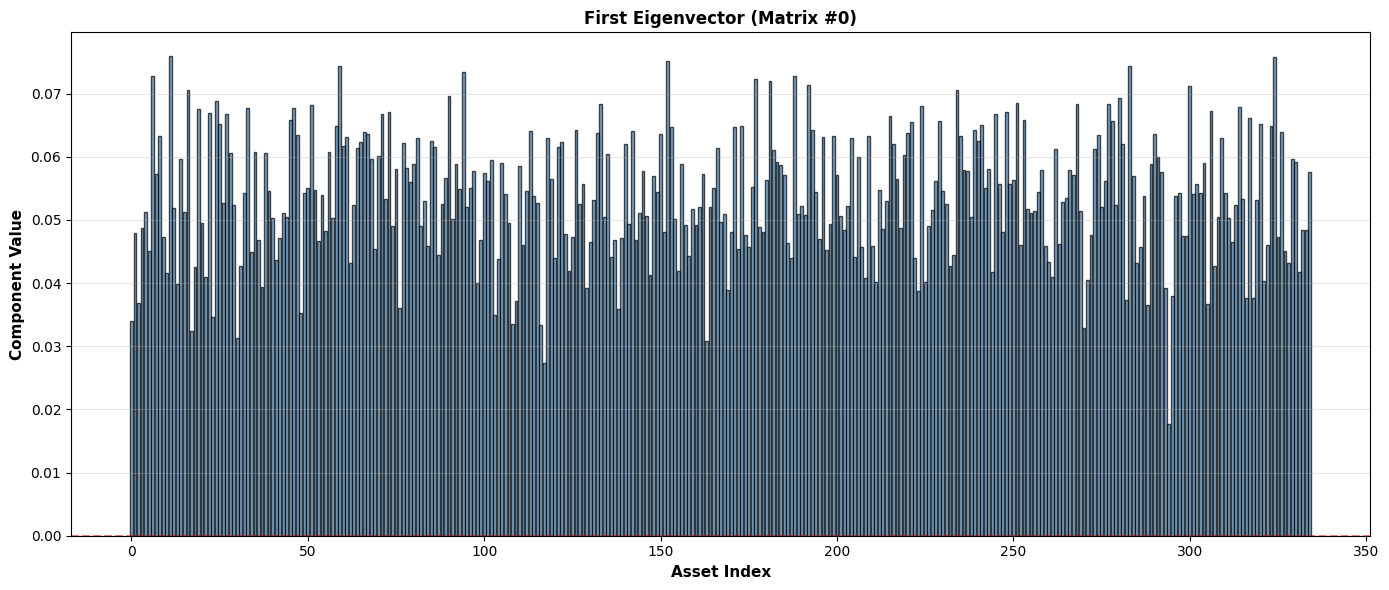

In [9]:
eigenvalues_np = eigenvalues_tensor.cpu().numpy()
eigenvectors_np = eigenvectors_tensor.cpu().numpy()

num_matrices = eigenvalues_np.shape[0]
num_assets = eigenvalues_np.shape[1]

# Parse global selection to determine analysis type and matrices
matrix_indices, _, analysis_type = parse_selected_corr_matrix(SELECTED_CORR_MATRIX, num_matrices)

# Pre-compute eigenvectors and properties for ALL matrices
pf_property_check = np.zeros(num_matrices, dtype=bool)
first_eigenvectors = np.full((num_assets, num_matrices), np.nan)
max_eigenvalue_multiplicity = np.zeros(num_matrices, dtype=int)

for i in range(num_matrices):
    eigenvalues = eigenvalues_np[i]
    eigenvectors = eigenvectors_np[i]

    # Get first eigenvector (largest eigenvalue)
    first_eigenvector = eigenvectors[:, 0].copy()

    # Normalize sign using sum (more robust than first element)
    if np.sum(first_eigenvector) < 0:
        first_eigenvector = -first_eigenvector

    first_eigenvectors[:, i] = first_eigenvector
    pf_property_check[i] = np.all(first_eigenvector >= -1e-2)
    max_eigenvalue_multiplicity[i] = np.sum(np.isclose(eigenvalues[0], eigenvalues, atol=1e-6))



def print_negative_tickers(vector, tickers, use_mean_label):
    neg_idx = np.where(vector < 0)[0]
    if len(neg_idx) > 0:
        label = 'mean component' if use_mean_label else 'components'
        print(f"\nTickers with NEGATIVE {label} ({len(neg_idx)} total):")
        for idx in neg_idx:
            print(f"  {idx:3d}. {tickers[idx]:6s} -> {vector[idx]:8.6f}")
    else:
        print("\nNo tickers with negative values")

def plot_property3_single(eigvec, title):
    """Render a simple histogram for a single matrix eigenvector."""
    fig, ax = plt.subplots(figsize=(14, 6))
    asset_idx = np.arange(num_assets)
    
    ax.bar(asset_idx, eigvec, alpha=0.7, color='steelblue', edgecolor='black')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Asset Index', fontsize=11, fontweight='bold')
    ax.set_ylabel('Component Value', fontsize=11, fontweight='bold')
    ax.axhline(0, color='red', linestyle='--', alpha=0.5)
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    return fig

def plot_property3_panels(first_panel_data, first_panel_title, mean_vec, std_vec, second_panel_title):
    """Render the two required plots for Property 3 without duplicating plotting code."""
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    asset_idx = np.arange(num_assets)

    # First panel: always overlay.
    for vec in first_panel_data:
        axes[0].plot(vec, alpha=0.3)

    axes[0].set_title(first_panel_title, fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Asset Index', fontsize=11, fontweight='bold')
    axes[0].set_ylabel('Component Value', fontsize=11, fontweight='bold')
    axes[0].axhline(0, color='red', linestyle='--', alpha=0.5)
    axes[0].grid(True, alpha=0.3, axis='y')

    # Second panel: always mean ± std.
    axes[1].bar(asset_idx, mean_vec, alpha=0.7, color='steelblue', edgecolor='black')
    axes[1].fill_between(asset_idx, mean_vec - std_vec, mean_vec + std_vec, alpha=0.3, color='steelblue')
    axes[1].set_title(second_panel_title, fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Asset Index', fontsize=11, fontweight='bold')
    axes[1].set_ylabel('Mean Value', fontsize=11, fontweight='bold')
    axes[1].axhline(0, color='red', linestyle='--', alpha=0.5)
    axes[1].grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    return fig

# ===== ANALYSIS OUTPUT =====
print(f"\n{'='*60}")
print("Perron-Frobenius Property Analysis")
print(f"{'='*60}")

subset_indices = matrix_indices
subset_vec = first_eigenvectors[:, subset_indices]
subset_pf = pf_property_check[subset_indices]
subset_mult = max_eigenvalue_multiplicity[subset_indices]
num_selected = len(subset_indices)
num_satisfying = np.sum(subset_pf)

if analysis_type == 'single':
    matrix_idx = subset_indices[0]
    eigvec = subset_vec[:, 0]

    print(f"\nMatrix #{matrix_idx}:")
    print(f"  Perron-Frobenius property satisfied: {subset_pf[0]}")
    print(f"  Largest eigenvalue multiplicity: {int(subset_mult[0])}")
    print(f"  Min component: {np.min(eigvec):.6f}, Max component: {np.max(eigvec):.6f}")

    print_negative_tickers(eigvec, tickers, use_mean_label=False)

    fig = plot_property3_single(eigvec, f'First Eigenvector (Matrix #{matrix_idx})')
    
    # Save the figure
    plot_path = RESULTS_FOLDER / '04_first_eigenvector_single.png'
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    print(f"\n✓ Plot saved to: {plot_path}")
    
    plt.show()

else:
    mean_vec = np.mean(subset_vec, axis=1)
    std_vec = np.std(subset_vec, axis=1)

    if analysis_type == 'all':
        print(f"\nMatrices satisfying Perron-Frobenius property: {num_satisfying}/{num_matrices} ({100*num_satisfying/num_matrices:.1f}%)")
        print(f"All matrices have multiplicity = 1: {np.all(subset_mult == 1)}")
        first_panel_title = 'First Eigenvectors (All Matrices)'
        second_panel_title = 'Mean First Eigenvector ± Std Dev (All Matrices)'
    else:
        print(f"\nMatrices #{subset_indices[0]} to #{subset_indices[-1]} ({num_selected} total)")
        print(f"Satisfying Perron-Frobenius property: {num_satisfying}/{num_selected} ({100*num_satisfying/num_selected:.1f}%)")
        print(f"All selected matrices have multiplicity = 1: {np.all(subset_mult == 1)}")
        first_panel_title = f'First Eigenvectors (Matrices #{subset_indices[0]}-#{subset_indices[-1]})'
        second_panel_title = f'Mean First Eigenvector ± Std Dev (Matrices #{subset_indices[0]}-#{subset_indices[-1]})'

    print_negative_tickers(mean_vec, tickers, use_mean_label=True)

    first_panel_data = [subset_vec[:, j] for j in range(num_selected)]

    fig = plot_property3_panels(
        first_panel_data=first_panel_data,
        first_panel_title=first_panel_title,
        mean_vec=mean_vec,
        std_vec=std_vec,
        second_panel_title=second_panel_title,
    )
    
    # Save the figure
    plot_path = RESULTS_FOLDER / '04_first_eigenvector_analysis.png'
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    print(f"\n✓ Plot saved to: {plot_path}")
    
    plt.show()

### Property 4: Correlations have a hierarchical structure

For a **single selected correlation matrix**, we visualize:
- the correlation matrix heatmap
- the hierarchical clustering dendrogram built from the distance matrix

Distance is computed from correlation as:

$$
d_{ij} = \sqrt{2(1 - \rho_{ij})}
$$

✓ Heatmap saved to: ..\results\data_13_17_w660_s1\matrix_0\05a_property4_heatmap.png


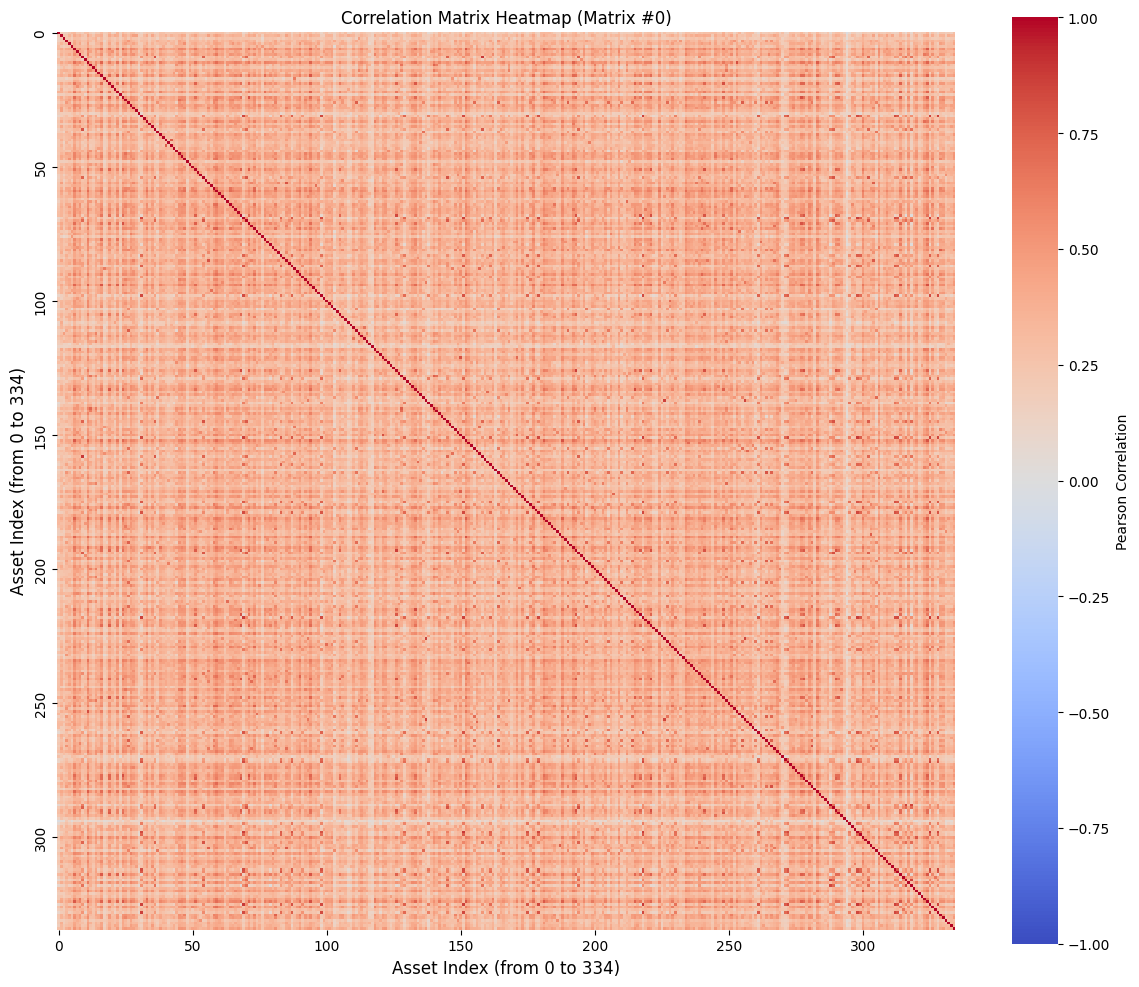

✓ Dendrogram saved to: ..\results\data_13_17_w660_s1\matrix_0\05b_property4_dendrogram.png


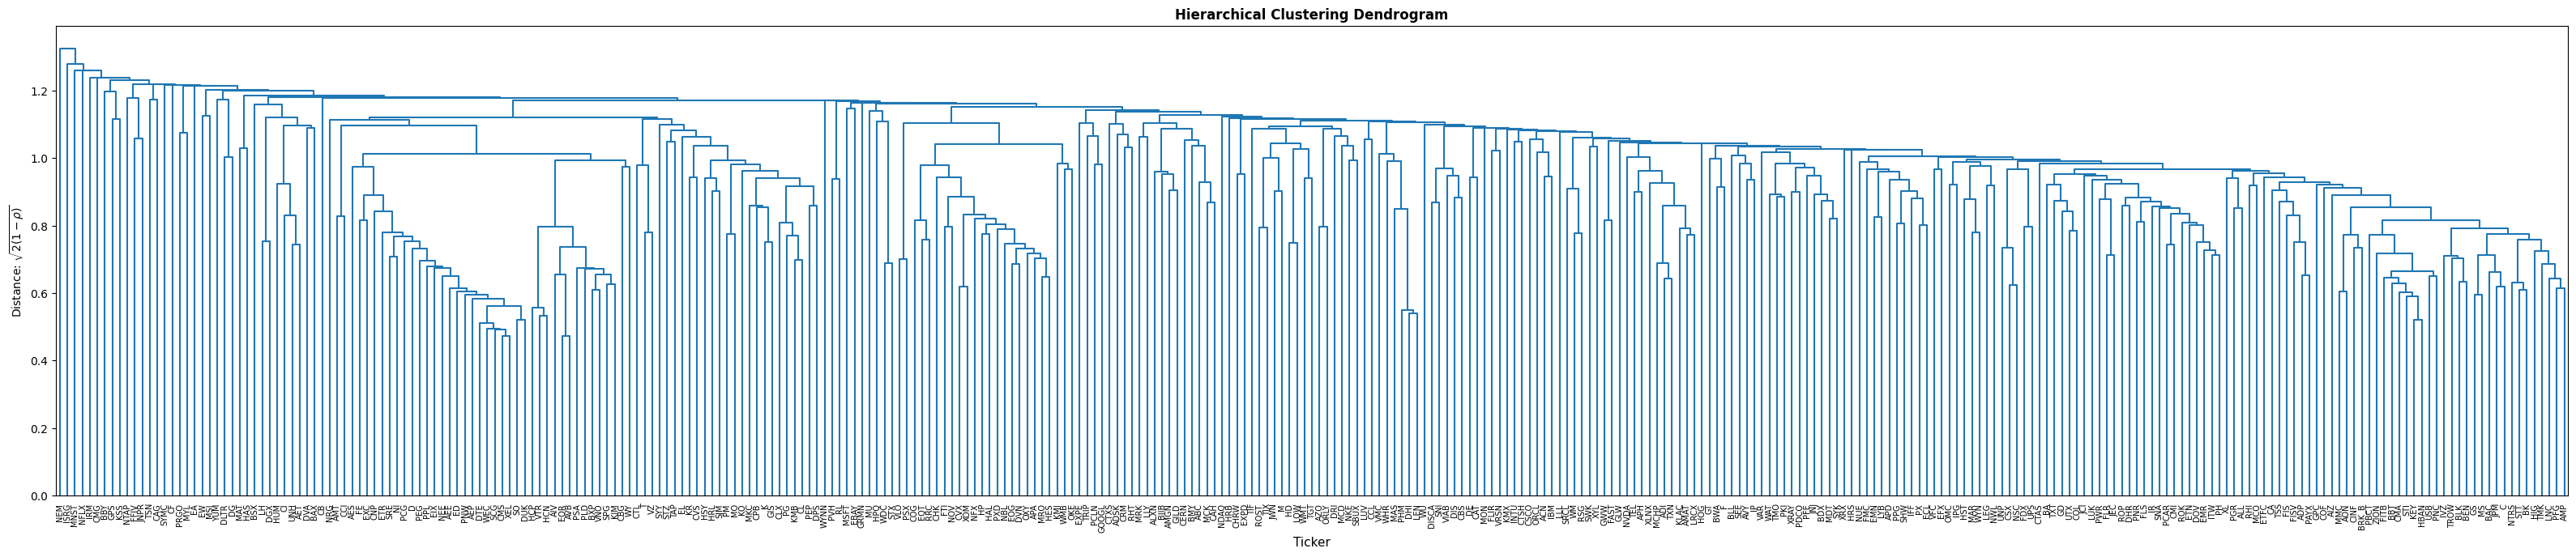

In [10]:
# Property 4 is evaluated only when a single matrix is selected
if SELECTED_CORR_MATRIX == 'all' or (isinstance(SELECTED_CORR_MATRIX, str) and ':' in SELECTED_CORR_MATRIX):
    print("Property 4 is available only for a single matrix selection.")
    print("Set SELECTED_CORR_MATRIX to an integer index (e.g., 5).")
else:
    try:
        from scipy.cluster.hierarchy import linkage, dendrogram
        from scipy.spatial.distance import squareform
    except ImportError as exc:
        raise ImportError(
            "SciPy is required for Property 4. Install it with: pip install scipy"
        ) from exc

    matrix_idx = int(SELECTED_CORR_MATRIX)
    if not (0 <= matrix_idx < corr_tensor.shape[0]):
        raise ValueError(
            f"Invalid SELECTED_CORR_MATRIX index: {matrix_idx}. Valid range is [0, {corr_tensor.shape[0] - 1}]."
        )

    # Extract and sanitize the selected correlation matrix
    corr_matrix = extract_and_sanitize_correlation_matrix(corr_tensor, matrix_idx)

    # Build distance matrix from correlations: d = sqrt(2 * (1 - corr))
    dist_matrix = build_distance_matrix(corr_matrix)

    # Convert to condensed form and compute hierarchical linkage
    condensed_dist = squareform(dist_matrix, checks=False)
    Z = linkage(condensed_dist, method='average')

    labels = tickers if len(tickers) == corr_matrix.shape[0] else [f"A{i}" for i in range(corr_matrix.shape[0])]

    # ===== Figure 1: Correlation Heatmap (same style as notebook 03) =====
    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(
        corr_matrix,
        annot=False,
        cmap='coolwarm',
        center=0,
        vmin=-1,
        vmax=1,
        square=True,
        xticklabels=50,
        yticklabels=50,
        cbar_kws={'label': 'Pearson Correlation'},
        ax=ax,
    )
    ax.set_title(f'Correlation Matrix Heatmap (Matrix #{matrix_idx})')
    ax.set_xlabel(f'Asset Index (from 0 to {corr_matrix.shape[0] - 1})', fontsize=12)
    ax.set_ylabel(f'Asset Index (from 0 to {corr_matrix.shape[0] - 1})', fontsize=12)
    plt.tight_layout()

    heatmap_path = RESULTS_FOLDER / '05a_property4_heatmap.png'
    plt.savefig(heatmap_path, dpi=150, bbox_inches='tight')
    print(f"✓ Heatmap saved to: {heatmap_path}")
    plt.show()

    # ===== Figure 2: Hierarchical Dendrogram =====
    fig, ax = plt.subplots(figsize=(40, 10))
    single_color = 'tab:blue'
    dendrogram(
        Z,
        labels=labels,
        leaf_rotation=90,
        leaf_font_size=7,
        ax=ax,
        color_threshold=0,
        above_threshold_color=single_color,
        link_color_func=lambda _: single_color,
    )
    ax.set_title('Hierarchical Clustering Dendrogram', fontsize=12, fontweight='bold')
    ax.set_xlabel('Ticker', fontsize=11)
    ax.set_ylabel(r'Distance: $\sqrt{2(1-\rho)}$')

    # Keep all tickers visible and reserve extra space for rotated labels.
    fig.subplots_adjust(bottom=0.3)

    dendrogram_path = RESULTS_FOLDER / '05b_property4_dendrogram.png'
    plt.savefig(dendrogram_path, dpi=300, bbox_inches='tight')
    print(f"✓ Dendrogram saved to: {dendrogram_path}")
    plt.show()

### Property 5: The Minimum Spanning Tree (MST) obtained from a correlation matrix satisfies the scale-free property

We test whether node degrees in MSTs extracted from correlation matrices show a scale-free behavior by analyzing the degree-frequency distribution in log-log scale.

For each selected matrix, we:
- convert correlations into distances
- compute the MST
- count node degrees
- average degree frequencies across selected matrices

#### MST Degree Distribution: Mathematical Summary

##### 1. The Sum of Degrees in a Tree
In graph theory, the **Handshaking Lemma** states that the sum of degrees of all nodes is equal to twice the number of edges:
$$\sum_{v \in V} \deg(v) = 2|E|$$

For a **Minimum Spanning Tree (MST)** with $N$ nodes, the number of edges is strictly fixed at:
$$|E| = N - 1$$

Consequently, the sum of all degrees in an MST is always a constant relative to the number of nodes:
$$\sum_{i=1}^{N} \deg_i = 2(N - 1)$$

---

##### 2. Interpretation as "Probability"
By dividing the degree counts by $(N-1)$, the code calculates the contribution of a specific degree to the total "connectivity capacity" of the tree. 

If you were to sum the normalized frequencies weighted by their degree $k$ (as found in the `all_counts` array), the result would be:
$$\sum \frac{\text{frequency}_k \times k}{N-1} = \frac{2(N-1)}{N-1} = 2$$

This approach is standard in **econophysics** and statistical mechanics applied to finance. It allows for:
*   **Comparability**: Comparing networks of different sizes ($N$) on a common scale.
*   **Scale-Free Verification**: Identifying if the network follows a power-law distribution $P(k) \sim k^{-\gamma}$ regardless of the total number of assets.


Property 5: MST Scale-Free Check
Selection: Matrix 0
Matrices analyzed: 1
Assets per matrix: 335
Non-zero degree frequencies: 13

Degree-Frequency Table:
Degree     Frequency       Log10(Degree)   Log10(Frequency)
-------------------------------------------------------
1          0.580838        0.000000        -0.235945      
2          0.218563        0.301030        -0.660424      
3          0.098802        0.477121        -1.005233      
4          0.038922        0.602060        -1.409803      
5          0.026946        0.698970        -1.569504      
6          0.008982        0.778151        -2.046625      
7          0.002994        0.845098        -2.523746      
8          0.002994        0.903090        -2.523746      
9          0.011976        0.954243        -1.921686      
10         0.002994        1.000000        -2.523746      
13         0.002994        1.113943        -2.523746      
18         0.002994        1.255273        -2.523746      
22         0.002994  

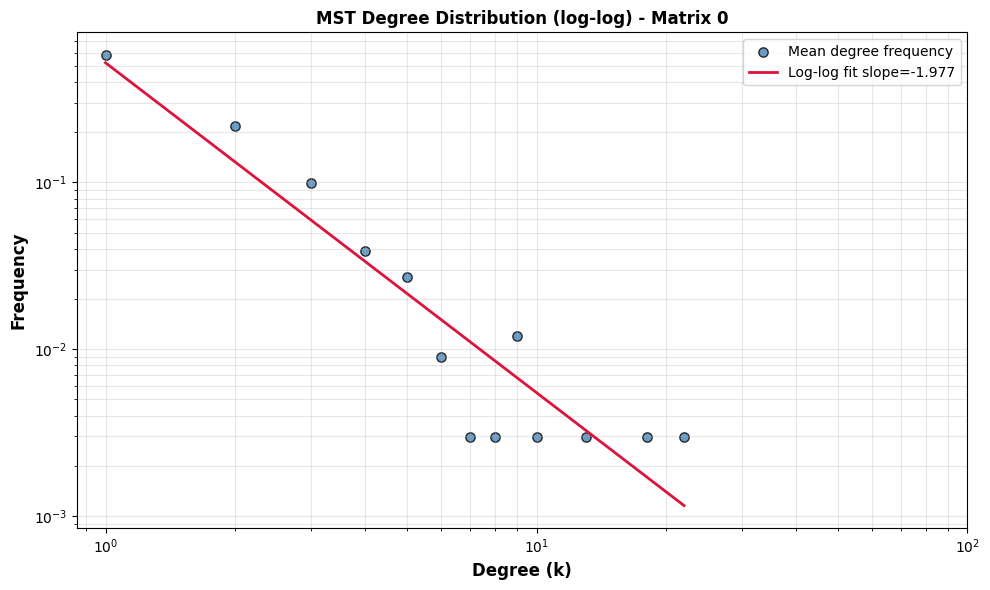

In [11]:
# Property 5: scale-free behavior of MST degree distribution
import networkx as nx


def compute_mst_degree_frequencies(corr_matrices):
    """
    Compute normalized degree frequencies for MSTs built from correlation matrices.

    Returns
    -------
    list of np.ndarray
        Each element contains degree frequencies for one matrix,
        normalized by (num_assets - 1).
    """
    num_matrices, num_assets, _ = corr_matrices.shape
    all_counts = []

    for i in range(num_matrices):
        # Extract and sanitize the correlation matrix
        corr = extract_and_sanitize_correlation_matrix(corr_matrices, i)

        # Build distance matrix from correlations
        dist = build_distance_matrix(corr)

        # Build graph and compute MST using networkx
        G = nx.from_numpy_array(dist)
        mst = nx.minimum_spanning_tree(G)

        # Count degrees in the MST
        degree_counts = {i: 0 for i in range(num_assets)}
        for edge in mst.edges():
            degree_counts[edge[0]] += 1
            degree_counts[edge[1]] += 1

        # Create degree frequency array
        degrees = np.array([degree_counts[i] for i in range(num_assets)])
        unique_degrees, degree_freqs = np.unique(degrees, return_counts=True)

        counts = np.zeros(num_assets)
        for deg, freq in zip(unique_degrees, degree_freqs):
            counts[deg] = freq

        all_counts.append(counts / (num_assets - 1))

    return all_counts


# Select matrices according to the global selection
num_matrices = corr_tensor.shape[0]
selected_indices, selection_label, _ = parse_selected_corr_matrix(SELECTED_CORR_MATRIX, num_matrices)
selected_corr = corr_tensor[selected_indices].cpu().numpy()

# Compute and average degree frequencies
degree_freq = compute_mst_degree_frequencies(selected_corr)
mean_counts = np.mean([df for df in degree_freq], axis=0)

# Use only strictly positive frequencies for log-log visualization
degrees = np.arange(0, mean_counts.shape[0])
valid = mean_counts > 0
x = degrees[valid]
y = mean_counts[valid]

print(f"\n{'='*60}")
print("Property 5: MST Scale-Free Check")
print(f"{'='*60}")
print(f"Selection: {selection_label}")
print(f"Matrices analyzed: {len(selected_indices)}")
print(f"Assets per matrix: {corr_tensor.shape[1]}")
print(f"Non-zero degree frequencies: {len(x)}")

# Print degree frequencies
print(f"\nDegree-Frequency Table:")
print(f"{'Degree':<10} {'Frequency':<15} {'Log10(Degree)':<15} {'Log10(Frequency)':<15}")
print("-" * 55)
for deg, freq in zip(x, y):
    print(f"{deg:<10.0f} {freq:<15.6f} {np.log10(deg):<15.6f} {np.log10(freq):<15.6f}")

# Optional slope estimate in log-log space
if len(x) >= 2:
    slope, intercept = np.polyfit(np.log10(x), np.log10(y), 1)
    print(f"Estimated log-log slope: {slope:.4f}")
else:
    slope, intercept = np.nan, np.nan
    print("Estimated log-log slope: not available (insufficient non-zero points)")

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(x, y, s=45, alpha=0.8, color='steelblue', edgecolor='black', label='Mean degree frequency')

if len(x) >= 2:
    y_fit = 10 ** (intercept + slope * np.log10(x))
    ax.plot(x, y_fit, color='crimson', linewidth=2, label=f'Log-log fit slope={slope:.3f}')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xticks([1, 10, 100], minor=False)
ax.set_xlabel('Degree (k)', fontsize=12, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax.set_title(f'MST Degree Distribution (log-log) - {selection_label}', fontsize=12, fontweight='bold')
ax.grid(True, which='both', alpha=0.3)
ax.legend()

plt.tight_layout()

plot_path = RESULTS_FOLDER / '06_property5_mst_scale_free.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
print(f"✓ Plot saved to: {plot_path}")
plt.show()